# Lecture 04 — Robot navigation by Q-learning

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Reinforcement learning (tabular Q-learning) · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Learn how an agent discovers a path through a blocked grid by trial and reward.

## Practical problem
A robot starts at the upper-left cell and aims for the lower-right cell; walls and movements are specified in an explicit transition dataset.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** A tiny deterministic grid is only a teaching environment, not a real robot controller.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 80 rows × 9 columns


,state,row,col,action,action_name,next_state,reward,done,goal
0,0,0,0,0,Up,0,-1,0,0
1,0,0,0,1,Down,5,-1,0,0
2,0,0,0,2,Left,0,-1,0,0
3,0,0,0,3,Right,1,-1,0,0
4,1,0,1,0,Up,1,-1,0,0


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['state', 'row', 'col', 'action', 'action_name', 'next_state', 'reward', 'done', 'goal']
Missing values per column:
state          0
row            0
col            0
action         0
action_name    0
next_state     0
reward         0
done           0
goal           0


## 2. Define states, actions, rewards and transitions
An RL agent learns by taking actions and receiving rewards. Here `dataset.csv` describes a **simulated environment**, not a labelled set of optimal actions. This is a tabular Q-learning demonstration.

States: 20 Actions: ['Up', 'Down', 'Left', 'Right']


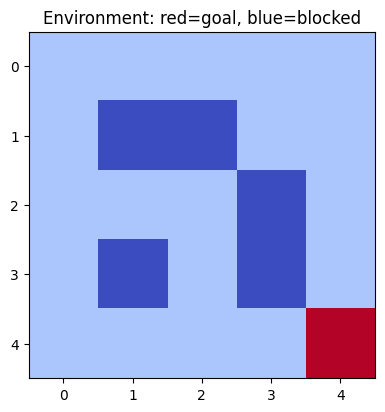

In [3]:
actions=['Up','Down','Left','Right']
transitions={(int(r.state),int(r.action)):(int(r.next_state),float(r.reward),bool(r.done)) for r in df.itertuples()}
valid_states=sorted(df['state'].unique().tolist())
print('States:',len(valid_states),'Actions:',actions)
board=np.zeros((5,5))
for r in range(5):
 for c in range(5):
  if r*5+c not in valid_states:board[r,c]=-1
board[4,4]=2
plt.imshow(board,cmap='coolwarm');plt.xticks(range(5));plt.yticks(range(5));plt.title('Environment: red=goal, blue=blocked');plt.grid(False);plt.show()

## 3. Train by exploring the environment
Q-learning updates an action value toward `reward + γ × best future Q`. Exploration (ε-greedy) helps an agent learn rather than repeating an initially arbitrary action.

In [4]:
rng=np.random.default_rng(17)
Q=np.zeros((25,4))
alpha=.24;gamma=.95;epsilon=.27
returns=[];successes=[]
for episode in range(1500):
    state=0;total=0;done=False
    for step in range(75):
        if rng.random()<epsilon: action=int(rng.integers(0,4))
        else: action=int(np.argmax(Q[state]))
        next_state,reward,done=transitions[(state,action)]
        target=reward+(0 if done else gamma*np.max(Q[next_state]))
        Q[state,action]+=alpha*(target-Q[state,action])
        state=next_state;total+=reward
        if done:break
    returns.append(total);successes.append(done)
print('Last 200 episodes success:',np.mean(successes[-200:]))

Last 200 episodes success: 1.0


## 4. Evaluate the learned policy
RL evaluation focuses on **episode return, task success rate or operational reward**, not a confusion matrix. There are no supervised target classes in these examples.

In [5]:
def greedy_episode(start=0,max_steps=35):
    state=start;path=[state];total=0
    for i in range(max_steps):
        a=int(np.argmax(Q[state]));next_state,reward,done=transitions[(state,a)]
        path.append(next_state);total+=reward;state=next_state
        if done:return path,total,True
    return path,total,False
path,reward,ok=greedy_episode(0)
print('Learned path:',path,'Return:',reward,'Goal reached:',ok)
print('Greedy evaluation: success from start =',int(ok))

Learned path: [0, 5, 10, 11, 12, 17, 22, 23, 24] Return: 3.0 Goal reached: True
Greedy evaluation: success from start = 1


## 5. Visualise what was learned

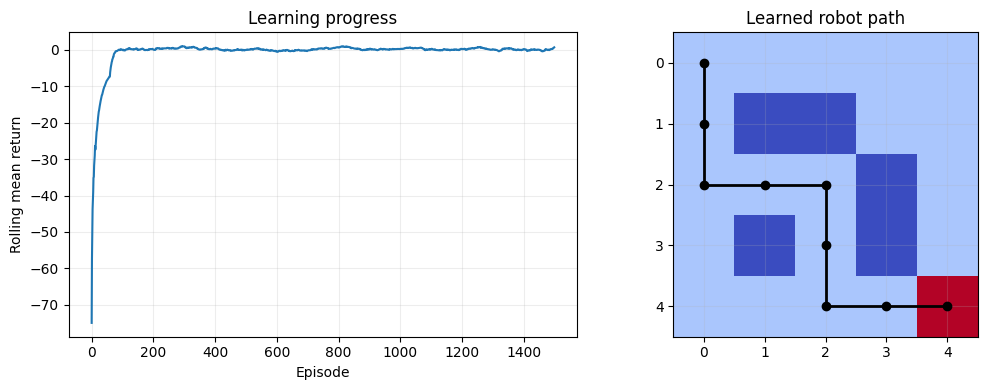

In [6]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(pd.Series(returns).rolling(60,min_periods=1).mean());ax[0].set(xlabel='Episode',ylabel='Rolling mean return',title='Learning progress')
ax[1].imshow(board,cmap='coolwarm')
xy=np.array([(s%5,s//5) for s in path]);ax[1].plot(xy[:,0],xy[:,1],'-o',color='black',linewidth=2)
ax[1].set(xticks=range(5),yticks=range(5),title='Learned robot path');plt.tight_layout();plt.show()

## 6. Apply the learned policy to new starting conditions

In [7]:
for start in [0,2,10,15]:
 path,score,ok=greedy_episode(start)
 print(f'Start {start:>2}: reached={ok}, steps={len(path)-1}, total reward={score}')

Start  0: reached=True, steps=8, total reward=3.0
Start  2: reached=True, steps=6, total reward=5.0
Start 10: reached=True, steps=6, total reward=5.0
Start 15: reached=True, steps=5, total reward=6.0


## Student investigation and discussion
1. Why is this not a supervised classification problem?
2. What would change if moving consumed different energy costs?
3. What is the role of epsilon (exploration)?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.